In [1]:
!pip install opencv-python pillow numpy scikit-learn tqdm scikit-image

In [2]:
import os
import cv2
import numpy as np
from tqdm import tqdm
from sklearn.neighbors import KDTree
from skimage.feature import local_binary_pattern

In [15]:
target_image_path = "/Users/ayushkumargupta/Desktop/Naruto.jpg"
tile_folder = "/Users/ayushkumargupta/Desktop/MossaicDataset"

tile_size = 90
grid_size = 100

In [16]:
def preprocess_tile(path, tile_size):

    img = cv2.imread(path)

    if img is None:
        return None

    img = cv2.resize(img, (tile_size, tile_size))

    # Contrast enhancement
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l,a,b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=1.5)
    cl = clahe.apply(l)

    enhanced = cv2.merge((cl,a,b))
    img = cv2.cvtColor(enhanced, cv2.COLOR_LAB2BGR)

    return img

In [17]:
def extract_features(img):

    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

    mean_color = np.mean(lab.reshape(-1,3), axis=0)

    hist = []

    for i in range(3):
        h = cv2.calcHist([lab],[i],None,[16],[0,256])
        hist.extend(h.flatten())

    hist = np.array(hist)
    hist = hist / (np.sum(hist) + 1e-6)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    lbp = local_binary_pattern(gray, 8, 1)
    lbp_hist,_ = np.histogram(lbp.ravel(),
                          bins=16,
                          range=(0,256))

    lbp_hist = lbp_hist / (np.sum(lbp_hist) + 1e-6)

    edges = cv2.Canny(gray, 100, 200)
    edge_density = np.mean(edges) / 255

    feature = np.concatenate([
        mean_color,
        hist,
        lbp_hist,
        [edge_density]
    ])

    return feature

In [18]:
tile_images = []
tile_features = []
tile_paths = []

for file in tqdm(os.listdir(tile_folder)):

    if not file.lower().endswith(('.png','.jpg','.jpeg','.webp')):
        continue

    path = os.path.join(tile_folder, file)

    tile = preprocess_tile(path, tile_size)

    if tile is None:
        continue

    feat = extract_features(tile)

    tile_images.append(tile)
    tile_features.append(feat)
    tile_paths.append(path)

tile_features = np.array(tile_features)

100%|██████████| 33/33 [00:01<00:00, 23.90it/s]


In [19]:
tree = KDTree(tile_features)

In [20]:
target = cv2.imread(target_image_path)

h, w = target.shape[:2]

aspect_ratio = w / h

grid_height = grid_size
grid_width = int(grid_size * aspect_ratio)

target = cv2.resize(
    target,
    (grid_width * tile_size, grid_height * tile_size)
)

In [21]:
mosaic = np.zeros_like(target)

usage_count = np.zeros(len(tile_images))

lambda_penalty = 0.1

for y in tqdm(range(grid_height)):

    for x in range(grid_width):

        y0 = y*tile_size
        y1 = (y+1)*tile_size

        x0 = x*tile_size
        x1 = (x+1)*tile_size

        patch = target[y0:y1, x0:x1]

        feat = extract_features(patch)

        dist, ind = tree.query([feat], k=8)

        best_tile = None
        best_score = 1e10

        for d,i in zip(dist[0], ind[0]):

            score = d + lambda_penalty*usage_count[i]

            if score < best_score:

                best_score = score
                best_tile = i

        usage_count[best_tile] += 1

        mosaic[y0:y1, x0:x1] = tile_images[best_tile]

100%|██████████| 100/100 [00:12<00:00,  7.95it/s]


In [22]:
blur = cv2.GaussianBlur(mosaic,(5,5),0)

alpha = 0.2

mosaic = cv2.addWeighted(mosaic,
                         1-alpha,
                         blur,
                         alpha,
                         0)

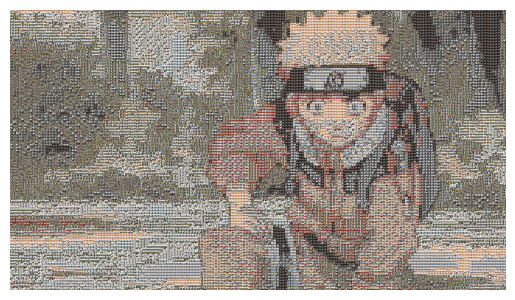

In [23]:
import matplotlib.pyplot as plt

# Convert BGR (OpenCV) to RGB (Matplotlib)
plt.imshow(cv2.cvtColor(mosaic, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [24]:
output_dir = "output"
os.makedirs(output_dir, exist_ok=True)

target_name = os.path.splitext(os.path.basename(target_image_path))[0]
counter = 1

while True:

    output_path = os.path.join(
        output_dir,
        f"{target_name}_mosaic_{counter}.jpg"
    )

    if not os.path.exists(output_path):
        break

    counter += 1


In [25]:
cv2.imwrite(
    output_path,
    mosaic,
    [
        cv2.IMWRITE_JPEG_QUALITY, 90,
        cv2.IMWRITE_JPEG_PROGRESSIVE, 1
    ]
)

print(f"Saved mosaic at: {output_path}")

Saved mosaic at: output/Naruto_mosaic_6.jpg
